<a href="https://colab.research.google.com/github/MurphyKlein/CS4782_final_project/blob/main/notebook/fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PatchTST Replication — Weather Dataset
**Target:** Replicate Table 4 (Self-supervised PatchTST, Fine-tuning) on Weather dataset

| Metric | Paper MSE | Paper MAE |
|--------|-----------|----------|
| 96     | 0.144     | 0.193    |
| 192    | 0.190     | 0.236    |
| 336    | 0.244     | 0.280    |
| 720    | 0.320     | 0.335    |

## 1. Mount Google Drive & Install Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/DL_Final_Project'
WEATHER_DATA_PATH = os.path.join(PROJECT_PATH, 'weather_data')
CHECKPOINT_DIR = os.path.join(PROJECT_PATH, 'fine_tune_checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print('Project path:', PROJECT_PATH)
print('Weather data path:', WEATHER_DATA_PATH)
print('Checkpoint dir:', CHECKPOINT_DIR)
print('Files in weather_data:', os.listdir(WEATHER_DATA_PATH))

Mounted at /content/drive
Project path: /content/drive/MyDrive/DL_Final_Project
Weather data path: /content/drive/MyDrive/DL_Final_Project/weather_data
Checkpoint dir: /content/drive/MyDrive/DL_Final_Project/fine_tune_checkpoints
Files in weather_data: ['mpi_roof_2020a.csv', 'mpi_roof_2020b.csv', 'mpi_roof_2021a.csv', 'mpi_roof_2021b.csv', 'mpi_roof_2022a.csv', 'mpi_roof_2022b.csv', 'mpi_roof_2023a.csv', 'mpi_roof_2023b.csv', 'mpi_roof_2024.csv', 'mpi_roof_2025.csv', 'mpi_roof.csv']


## 2. Merge All Weather CSV Files

In [ ]:
import pandas as pd
import numpy as np
import os
import glob

# Find all CSVs in the weather_data folder
csv_files = sorted(glob.glob(os.path.join(WEATHER_DATA_PATH, '*.csv')))
print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    print(' -', os.path.basename(f))

# Load and merge all CSVs
dfs = []
for f in csv_files:
    # Added encoding='latin-1' to handle non-utf-8 characters (like degree symbols)
    try:
        df = pd.read_csv(f, encoding='latin-1')
        print(f'\n{os.path.basename(f)}: shape={df.shape}')
        dfs.append(df)
    except Exception as e:
        print(f'Error reading {f}: {e}')

# Strategy: if files have a datetime/date column, sort and concat; else just concat
if len(dfs) == 0:
    print('No dataframes loaded. Check file paths or encodings.')
    merged_df = pd.DataFrame()
elif len(dfs) == 1:
    merged_df = dfs[0]
else:
    # Try to find a date column
    date_col = None
    for col in dfs[0].columns:
        if 'date' in col.lower() or 'time' in col.lower():
            date_col = col
            break

    if date_col:
        print(f'\nMerging on date column: {date_col}')
        merged_df = pd.concat(dfs, ignore_index=True)
        # Use dayfirst=True to correctly parse DD.MM.YYYY format
        merged_df[date_col] = pd.to_datetime(merged_df[date_col], dayfirst=True, errors='coerce')
        merged_df = merged_df.sort_values(date_col).reset_index(drop=True)
        merged_df = merged_df.drop_duplicates(subset=[date_col]).reset_index(drop=True)
    else:
        print('\nNo date column found, concatenating row-wise.')
        merged_df = pd.concat(dfs, ignore_index=True)

if not merged_df.empty:
    print(f'\n=== Merged DataFrame ===' )
    print(f'Shape: {merged_df.shape}')
    print(f'Columns ({len(merged_df.columns)}): {list(merged_df.columns)}')
    print(f'\nFirst 5 rows:')
    display(merged_df.head())
    print(f'\nNull counts in Date column: {merged_df[date_col].isnull().sum() if date_col else "N/A"}')

Found 11 CSV files:
 - mpi_roof.csv
 - mpi_roof_2020a.csv
 - mpi_roof_2020b.csv
 - mpi_roof_2021a.csv
 - mpi_roof_2021b.csv
 - mpi_roof_2022a.csv
 - mpi_roof_2022b.csv
 - mpi_roof_2023a.csv
 - mpi_roof_2023b.csv
 - mpi_roof_2024.csv
 - mpi_roof_2025.csv

mpi_roof.csv: shape=(17403, 22)

mpi_roof_2020a.csv: shape=(26200, 22)

mpi_roof_2020b.csv: shape=(26496, 22)

mpi_roof_2021a.csv: shape=(26064, 22)

mpi_roof_2021b.csv: shape=(26496, 22)

mpi_roof_2022a.csv: shape=(26070, 22)

mpi_roof_2022b.csv: shape=(26415, 22)

mpi_roof_2023a.csv: shape=(26061, 22)

mpi_roof_2023b.csv: shape=(26639, 22)

mpi_roof_2024.csv: shape=(52704, 22)

mpi_roof_2025.csv: shape=(52560, 22)

Merging on date column: Date Time

=== Merged DataFrame ===
Shape: (332957, 22)
Columns (22): ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'rain (mm)', 'rain

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),...,wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC),CO2 (ppm)
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45,428.1
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51,428.0
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60,427.6
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70,430.0
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81,432.2



Null counts in Date column: 0


## 3. Data Preprocessing

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ── Identify numeric feature columns ──────────────────────────────────────────
date_col = None
for col in merged_df.columns:
    if 'date' in col.lower() or 'time' in col.lower():
        date_col = col
        break

if date_col:
    feature_cols = [c for c in merged_df.columns if c != date_col]
else:
    feature_cols = list(merged_df.columns)

# Drop non-numeric columns
numeric_df = merged_df[feature_cols].select_dtypes(include=[np.number])
feature_cols = list(numeric_df.columns)
print(f'Number of features (channels M): {len(feature_cols)}')
print('Feature columns:', feature_cols)

# Dataset assumed pre-cleaned — report NaN counts but do NOT fill
data = numeric_df.values
nan_counts = np.isnan(data).sum()
if nan_counts > 0:
    print(f'WARNING: {nan_counts} NaN values found in data. Please clean upstream.')
else:
    print('No NaN values found. Data is clean.')

print(f'Data shape: {data.shape}  (timesteps, channels)')


Number of features (channels M): 21
Feature columns: ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'rain (mm)', 'raining (s)', 'SWDR (W/m²)', 'PAR (µmol/m²/s)', 'max. PAR (µmol/m²/s)', 'Tlog (degC)', 'CO2 (ppm)']
No NaN values found. Data is clean.
Data shape: (332957, 21)  (timesteps, channels)


In [ ]:
# ── Train / Val / Test split  (70 / 10 / 20 — standard for Weather) ──────────
n = len(data)
n_train = int(n * 0.7)
n_val   = int(n * 0.1)
n_test  = n - n_train - n_val

train_data = data[:n_train]
val_data   = data[n_train - 512 : n_train + n_val]  # overlap for context
test_data  = data[n_train + n_val - 512 :]           # overlap for context

print(f'Total timesteps : {n}')
print(f'Train           : {len(train_data)}')
print(f'Val             : {len(val_data)}')
print(f'Test            : {len(test_data)}')

# ── Scaler fit on training data only ─────────────────────────────────────────
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)

Total timesteps : 332957
Train           : 233069
Val             : 33807
Test            : 67105


In [ ]:
class TimeSeriesDataset(Dataset):
    """Sliding-window dataset for time series forecasting."""
    def __init__(self, data, seq_len, pred_len):
        self.data     = torch.FloatTensor(data)   # (T, M)
        self.seq_len  = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]                        # (L, M)
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]  # (T, M)
        return x, y

## 4. PatchTST Model Architecture

This section implements the core PatchTST components according to the paper specification:
- **Non-overlapping patches:** patch_len=12, stride=12 (no overlap)
- **Input sequence:** 512 timesteps → 42 patches
- **Masking ratio:** 40% during pre-training
- **Channel independence:** Each channel processed separately through shared transformer

In [ ]:
import torch
import torch.nn as nn
import math


class PatchEmbedding(nn.Module):
    """Non-overlapping patch embedding for PatchTST."""
    def __init__(self, patch_len, d_model, dropout=0.0):
        super().__init__()
        self.patch_len = patch_len
        self.proj = nn.Linear(patch_len, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B*M, L) where L may not be exactly divisible by patch_len
        B, L = x.shape
        # Truncate to nearest multiple of patch_len (e.g., 512 → 504 for patch_len=12)
        L_truncated = (L // self.patch_len) * self.patch_len
        x = x[:, :L_truncated]  # (B*M, L_truncated)
        # Create non-overlapping patches
        x = x.reshape(B, -1, self.patch_len)  # (B, N, patch_len) where N = L_truncated // patch_len
        x = self.proj(x)  # (B, N, d_model)
        return self.dropout(x)


class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""
    def __init__(self, d_model, max_len=1024, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (B, N, d_model)
        x = x + self.pe[:x.size(1)].unsqueeze(0)
        return self.dropout(x)


class PatchTST(nn.Module):
    """
    Channel-independent PatchTST for time series forecasting.
    Paper: "A Time Series is Worth 64 Words: Long-term Forecasting with Transformers"
    """
    def __init__(
        self,
        num_channels,
        seq_len,
        pred_len,
        patch_len=12,
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=256,
        dropout=0.2,
    ):
        super().__init__()
        self.num_channels = num_channels
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.patch_len = patch_len
        self.num_patches = seq_len // patch_len

        # Patch embedding (non-overlapping)
        self.patch_embed = PatchEmbedding(patch_len, d_model, dropout)
        self.pos_enc = PositionalEncoding(d_model, max_len=self.num_patches + 10, dropout=dropout)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Forecasting head
        self.head = nn.Linear(self.num_patches * d_model, pred_len)

    def forward(self, x):
        # x: (B, L, M)
        B, L, M = x.shape

        # Instance normalization per channel
        mean = x.mean(dim=1, keepdim=True)  # (B, 1, M)
        std = x.std(dim=1, keepdim=True) + 1e-5
        x = (x - mean) / std

        # Channel-independence: treat each channel independently
        x = x.permute(0, 2, 1).reshape(B * M, L)  # (B*M, L)

        # Patch embedding (handles truncation internally)
        x = self.patch_embed(x)  # (B*M, N, d_model)
        x = self.pos_enc(x)

        # Transformer
        x = self.transformer(x)  # (B*M, N, d_model)

        # Flatten and project
        x = x.reshape(B * M, -1)  # (B*M, N*d_model)
        x = self.head(x)  # (B*M, pred_len)

        # Reshape and denormalize
        x = x.reshape(B, M, self.pred_len).permute(0, 2, 1)  # (B, pred_len, M)
        x = x * std + mean

        return x


class MaskedPatchTST(nn.Module):
    """Self-supervised version for masked patch reconstruction pre-training."""
    def __init__(
        self,
        num_channels,
        seq_len,
        patch_len=12,
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=256,
        dropout=0.2,
    ):
        super().__init__()
        self.num_channels = num_channels
        self.seq_len = seq_len
        self.patch_len = patch_len
        self.num_patches = seq_len // patch_len

        self.patch_embed = PatchEmbedding(patch_len, d_model, dropout)
        self.pos_enc = PositionalEncoding(d_model, max_len=self.num_patches + 10, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Reconstruction head
        self.head = nn.Linear(d_model, patch_len)

    def forward(self, x, mask_ratio=0.4):
        B, L, M = x.shape

        # Instance normalization
        mean = x.mean(dim=1, keepdim=True)
        std = x.std(dim=1, keepdim=True) + 1e-5
        x = (x - mean) / std

        # Channel-independence
        x = x.permute(0, 2, 1).reshape(B * M, L)  # (B*M, L)

        # Truncate to match expected patch dimensions (L may not be exactly divisible by patch_len)
        L_truncated = self.num_patches * self.patch_len
        x = x[:, :L_truncated]  # (B*M, L_truncated)

        # Non-overlapping patches
        x = x.reshape(B * M, self.num_patches, self.patch_len)  # (B*M, N, P)
        target = x.clone()

        # Random masking
        num_masked = int(self.num_patches * mask_ratio)
        if num_masked > 0:
            mask_idx = torch.randperm(self.num_patches)[:num_masked]
            x[:, mask_idx, :] = 0.0
        else:
            mask_idx = torch.tensor([], dtype=torch.long)

        # Embedding and encoding
        z = self.patch_embed(x.reshape(B * M, -1))  # (B*M, N, d_model)
        z = self.pos_enc(z)
        z = self.transformer(z)  # (B*M, N, d_model)

        # Reconstruction
        out = self.head(z)  # (B*M, N, P)

        # Loss only on masked patches
        if len(mask_idx) > 0:
            loss = ((out[:, mask_idx, :] - target[:, mask_idx, :]) ** 2).mean()
        else:
            loss = torch.tensor(0.0, device=x.device)

        return loss, z


# Verify patch count
test_seq_len = 512
test_patch_len = 12
test_patches = test_seq_len // test_patch_len
print(f"✓ Patch configuration: seq_len={test_seq_len}, patch_len={test_patch_len} → {test_patches} patches")
print(f"✓ Note: Input will be truncated from 512 → {test_patches * test_patch_len} (504) for exact divisibility")
print(f"✓ Model architecture ready")

✓ Patch configuration: seq_len=512, patch_len=12 → 42 patches
✓ Note: Input will be truncated from 512 → 504 (504) for exact divisibility
✓ Model architecture ready


## 5. Training Infrastructure

In [ ]:
import time


class EarlyStopping:
    """Early stopping to prevent overfitting."""
    def __init__(self, patience=10, min_delta=1e-4, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.verbose:
                print(f'    EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
            return False


def save_checkpoint(model, optimizer, epoch, val_loss, pred_len, path):
    """Save checkpoint."""
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optim_state': optimizer.state_dict(),
        'val_loss': val_loss,
        'pred_len': pred_len,
    }, path)
    print(f'    ✓ Checkpoint saved → {path}')


def load_checkpoint(model, optimizer, path, device):
    """Load checkpoint."""
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optim_state'])
    print(f'    ✓ Loaded checkpoint (epoch {ckpt["epoch"]}, val_loss {ckpt["val_loss"]:.4f})')
    return ckpt['epoch'], ckpt['val_loss']


def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device):
    """Evaluate MSE and MAE."""
    model.eval()
    total_mse = total_mae = 0.0
    n = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        total_mse += ((pred - y) ** 2).mean(dim=(1, 2)).sum().item()
        total_mae += (pred - y).abs().mean(dim=(1, 2)).sum().item()
        n += x.size(0)
    return total_mse / n, total_mae / n


print('✓ Training infrastructure ready')

✓ Training infrastructure ready


In [ ]:
CHECKPOINT_DIR = os.path.join(PROJECT_PATH, 'fine_tune_checkpoints')


## 6. Self-Supervised Pre-training (Masked Patch Reconstruction)

**Paper Configuration:**
- Input sequence length: 512 timesteps
- Patch size: 12 (non-overlapping) → 42 patches
- Masking ratio: 40%
- Pre-training epochs: 100
- Dataset: 70% of training data

This phase learns general time series representations via masked patch reconstruction before fine-tuning on specific forecasting tasks.

In [ ]:
# Pre-training configuration (from paper)
PRETRAIN_CFG = dict(
    seq_len=512,
    patch_len=12,
    d_model=128,
    n_heads=8,
    n_layers=3,
    d_ff=256,
    dropout=0.2,
    batch_size=128,
    lr=1e-3,
    epochs=100,
    mask_ratio=0.4,
)

# Add patience for early stopping during pre-training (e.g., 20% of total epochs)
PRETRAIN_CFG['patience'] = PRETRAIN_CFG['epochs'] // 5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Pre-training config: {PRETRAIN_CFG}')

pretrain_path = os.path.join(CHECKPOINT_DIR, 'patchtst_pretrained_backbone.pt')

# Pre-training dataset
print(f'\n{"="*70}')
print(f'SELF-SUPERVISED PRE-TRAINING (Masked Patch Reconstruction)')
print(f'{"="*70}')

M = len(feature_cols)
pretrain_ds = TimeSeriesDataset(train_scaled, PRETRAIN_CFG['seq_len'], 96) # 96 is a dummy pred_len for pre-training
pretrain_loader = DataLoader(pretrain_ds, batch_size=PRETRAIN_CFG['batch_size'],
                            shuffle=True, drop_last=True, num_workers=2, pin_memory=True)

print(f'Pre-training dataset: {len(pretrain_ds)} samples')
print(f'Channels (M): {M}')
print(f'Sequence length: {PRETRAIN_CFG["seq_len"]}')
print(f'Patch configuration: {PRETRAIN_CFG["seq_len"]} / {PRETRAIN_CFG["patch_len"]} = {PRETRAIN_CFG["seq_len"] // PRETRAIN_CFG["patch_len"]} patches')
print(f'Masking ratio: {PRETRAIN_CFG["mask_ratio"]:.1%}')
print(f'Early stopping patience: {PRETRAIN_CFG["patience"]} epochs')

# Initialize pre-training model
pretrain_model = MaskedPatchTST(
    num_channels=M,
    seq_len=PRETRAIN_CFG['seq_len'],
    patch_len=PRETRAIN_CFG['patch_len'],
    d_model=PRETRAIN_CFG['d_model'],
    n_heads=PRETRAIN_CFG['n_heads'],
    n_layers=PRETRAIN_CFG['n_layers'],
    d_ff=PRETRAIN_CFG['d_ff'],
    dropout=PRETRAIN_CFG['dropout'],
).to(device)

pretrain_optimizer = torch.optim.Adam(pretrain_model.parameters(), lr=PRETRAIN_CFG['lr'])
pretrain_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    pretrain_optimizer, T_max=PRETRAIN_CFG['epochs']
)

# Ensure the checkpoint directory exists before attempting to save
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Load or train
if os.path.exists(pretrain_path):
    print(f'\n✓ Loading pre-trained backbone from {pretrain_path}')
    pretrain_model.load_state_dict(torch.load(pretrain_path, map_location=device))
else:
    print(f'\nTraining for {PRETRAIN_CFG["epochs"]} epochs...\n')

    pretrain_early_stopping = EarlyStopping(patience=PRETRAIN_CFG['patience'], verbose=False)
    best_pretrain_loss = float('inf') # Track best loss to compare against for saving

    for ep in range(PRETRAIN_CFG['epochs']):
        pretrain_model.train()
        total_loss = 0.0
        num_samples = 0

        for x, _ in pretrain_loader:
            x = x.to(device)
            pretrain_optimizer.zero_grad()
            loss, _ = pretrain_model(x, mask_ratio=PRETRAIN_CFG['mask_ratio'])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(pretrain_model.parameters(), max_norm=1.0)
            pretrain_optimizer.step()
            total_loss += loss.item() * x.size(0)
            num_samples += x.size(0)

        pretrain_scheduler.step()
        avg_loss = total_loss / num_samples if num_samples > 0 else 0.0

        # Print loss every epoch
        print(f'Epoch {ep+1:3d}/{PRETRAIN_CFG["epochs"]} | Loss: {avg_loss:.6f}')

        # Early stopping logic
        if pretrain_early_stopping(avg_loss):
            best_pretrain_loss = avg_loss
            torch.save(pretrain_model.state_dict(), pretrain_path)
            print(f'    ✓ Pre-trained model (best so far) saved \u2192 {pretrain_path}')

        if pretrain_early_stopping.early_stop:
            print(f'\nEarly stopping triggered after {ep+1} epochs due to no improvement in loss.')
            break

    # Final message after the loop indicating where the best model is saved
    if best_pretrain_loss == float('inf'): # This means early stopping never found an improvement or was skipped
        torch.save(pretrain_model.state_dict(), pretrain_path) # Save the last state if no improvement was ever made
        print(f'\n✓ Pre-trained backbone (final epoch state) saved \u2192 {pretrain_path}')
    else:
        # The best model was already saved during the loop by early stopping
        print(f'\n✓ Pre-trained backbone (best state from early stopping) is at \u2192 {pretrain_path}')

Device: cuda
Pre-training config: {'seq_len': 512, 'patch_len': 12, 'd_model': 128, 'n_heads': 8, 'n_layers': 3, 'd_ff': 256, 'dropout': 0.2, 'batch_size': 128, 'lr': 0.001, 'epochs': 100, 'mask_ratio': 0.4, 'patience': 20}

SELF-SUPERVISED PRE-TRAINING (Masked Patch Reconstruction)
Pre-training dataset: 232462 samples
Channels (M): 21
Sequence length: 512
Patch configuration: 512 / 12 = 42 patches
Masking ratio: 40.0%
Early stopping patience: 20 epochs

Training for 100 epochs...

Epoch   1/100 | Loss: 0.372120
    ✓ Pre-trained model (best so far) saved → /content/drive/MyDrive/DL_Final_Project/fine_tune_checkpoints/patchtst_pretrained_backbone.pt
Epoch   2/100 | Loss: 0.246028
    ✓ Pre-trained model (best so far) saved → /content/drive/MyDrive/DL_Final_Project/fine_tune_checkpoints/patchtst_pretrained_backbone.pt
Epoch   3/100 | Loss: 0.226566
    ✓ Pre-trained model (best so far) saved → /content/drive/MyDrive/DL_Final_Project/fine_tune_checkpoints/patchtst_pretrained_backbone.pt


## 7. Part (b): Two-Phase Fine-tuning

**Paper Specification for Part (b):**
- Phase 1 (Linear Probing): 10 epochs with encoder frozen, head trainable only
- Phase 2 (End-to-end): 20 epochs with all layers unfrozen
- This two-step strategy outperforms direct fine-tuning (paper citation: Kumar et al., 2022)

**Prediction horizons:** [96, 192, 336, 720] hours
**Evaluation:** MSE and MAE on test set

In [ ]:
pretrain_path = os.path.join(CHECKPOINT_DIR, 'patchtst_pretrained_backbone.pt')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PRED_LENS = [96, 192, 336, 720]
PAPER_RESULTS = {
    96: (0.144, 0.193),
    192: (0.190, 0.236),
    336: (0.244, 0.280),
    720: (0.320, 0.335),
}

FINE_TUNE_CFG = dict(
    seq_len=512,
    patch_len=12,
    d_model=128,
    n_heads=8,
    n_layers=3,
    d_ff=256,
    dropout=0.2,
    batch_size=128,
    lr_fine_tune=1e-4,
    # A higher learning rate for the head only if desired during linear probing
    # For simplicity, we'll keep one optimizer with `lr_fine_tune` for both phases,
    # which is common for smaller LRs during transfer learning.
    linear_probe_epochs=10,
    finetune_epochs=20,
    patience=10,
)

# device is already defined from pre-training section

print(f'\n{"="*70}')
print(f'TWO-PHASE FINE-TUNING (Linear Probing + End-to-End)')
print(f'{"="*70}')
print(f'Fine-tuning config: {FINE_TUNE_CFG}')

M = len(feature_cols) # num_channels
results = {} # Store results for each prediction length
history_all_horizons = {} # Store training history for each horizon

for pred_len in PRED_LENS:
    print(f'\n{"-"*70}')
    print(f'Processing Prediction Horizon: {pred_len} hours (T={pred_len})')
    print(f'{"-"*70}')

    # ── Datasets and DataLoaders ──────────────────────────────────────────
    train_ds = TimeSeriesDataset(train_scaled, FINE_TUNE_CFG['seq_len'], pred_len)
    val_ds   = TimeSeriesDataset(val_scaled,   FINE_TUNE_CFG['seq_len'], pred_len)
    test_ds  = TimeSeriesDataset(test_scaled,  FINE_TUNE_CFG['seq_len'], pred_len)

    train_loader = DataLoader(train_ds, batch_size=FINE_TUNE_CFG['batch_size'], shuffle=True, drop_last=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=FINE_TUNE_CFG['batch_size'], shuffle=False, drop_last=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=FINE_TUNE_CFG['batch_size'], shuffle=False, drop_last=False, num_workers=2, pin_memory=True)

    print(f'Train samples: {len(train_ds)}, Val samples: {len(val_ds)}, Test samples: {len(test_ds)}')

    # ── Model Initialization and Pre-trained Backbone Loading ─────────────
    model = PatchTST(
        num_channels=M,
        seq_len=FINE_TUNE_CFG['seq_len'],
        pred_len=pred_len,
        patch_len=FINE_TUNE_CFG['patch_len'],
        d_model=FINE_TUNE_CFG['d_model'],
        n_heads=FINE_TUNE_CFG['n_heads'],
        n_layers=FINE_TUNE_CFG['n_layers'],
        d_ff=FINE_TUNE_CFG['d_ff'],
        dropout=FINE_TUNE_CFG['dropout'],
    ).to(device)

    # Load pre-trained encoder weights
    # We need to adapt the state_dict keys because MaskedPatchTST has a reconstruction head
    # and PatchTST has a forecasting head, but the encoder part is shared.
    pretrain_state_dict = torch.load(pretrain_path, map_location=device)
    model_state_dict = model.state_dict()

    # Filter out mismatching keys (especially the heads)
    pretrained_encoder_keys = {k: v for k, v in pretrain_state_dict.items() if 'head' not in k}
    model_state_dict.update(pretrained_encoder_keys)
    model.load_state_dict(model_state_dict)
    print(f'    ✓ Loaded pre-trained encoder weights into PatchTST model.')

    # ── Optimizer, Loss, and Early Stopping ───────────────────────────────
    criterion = nn.MSELoss()
    optimizer_ft = torch.optim.Adam(model.parameters(), lr=FINE_TUNE_CFG['lr_fine_tune']) # Initial LR for fine-tuning
    early_stopping = EarlyStopping(patience=FINE_TUNE_CFG['patience'], min_delta=1e-4, verbose=True)

    # Store history for current horizon
    history = []
    best_val_loss = float('inf')
    best_path = os.path.join(CHECKPOINT_DIR, f'patchtst_T{pred_len}_best.pt')

    # ── Phase 1: Linear Probing (Encoder Frozen, Head Trainable) ──────────
    print(f'\n  --- Phase 1: Linear Probing ({FINE_TUNE_CFG["linear_probe_epochs"]} epochs) ---')
    for param in model.patch_embed.parameters(): param.requires_grad = False
    for param in model.pos_enc.parameters(): param.requires_grad = False
    for param in model.transformer.parameters(): param.requires_grad = False
    # Ensure head parameters are trainable
    for param in model.head.parameters(): param.requires_grad = True

    # Optimizer will only update parameters with requires_grad=True

    for ep in range(FINE_TUNE_CFG['linear_probe_epochs']):
        train_loss = train_one_epoch(model, train_loader, optimizer_ft, criterion, device)
        val_mse, val_mae = evaluate(model, val_loader, device)
        val_loss = val_mse # Use MSE as validation loss

        print(f'  Epoch {ep+1:2d}/{FINE_TUNE_CFG["linear_probe_epochs"]} (Linear Probing) | Train Loss: {train_loss:.6f} | Val MSE: {val_mse:.6f} | Val MAE: {val_mae:.6f}')
        history.append({'epoch': ep+1, 'phase': 'linear_probe', 'train_loss': train_loss, 'val_mse': val_mse, 'val_mae': val_mae})

        if early_stopping(val_loss):
            best_val_loss = val_loss
            save_checkpoint(model, optimizer_ft, ep+1, best_val_loss, pred_len, best_path)
        if early_stopping.early_stop:
            print('    Early stopping triggered for linear probing.')
            break

    # Load best model from linear probing before end-to-end fine-tuning
    if os.path.exists(best_path):
        load_checkpoint(model, optimizer_ft, best_path, device)
    else:
        print(f"    Warning: No best checkpoint found for T={pred_len} after linear probing. Continuing with last state.")

    # Reset early stopping for the next phase
    early_stopping = EarlyStopping(patience=FINE_TUNE_CFG['patience'], min_delta=1e-4, verbose=True)


    # ── Phase 2: End-to-end Fine-tuning (All Layers Unfrozen) ─────────────
    print(f'\n  --- Phase 2: End-to-end Fine-tuning ({FINE_TUNE_CFG["finetune_epochs"]} epochs) ---')
    # Unfreeze all model parameters
    for param in model.parameters():
        param.requires_grad = True

    for ep in range(FINE_TUNE_CFG['finetune_epochs']):
        train_loss = train_one_epoch(model, train_loader, optimizer_ft, criterion, device)
        val_mse, val_mae = evaluate(model, val_loader, device)
        val_loss = val_mse # Use MSE as validation loss

        print(f'  Epoch {ep+1:2d}/{FINE_TUNE_CFG["finetune_epochs"]} (Fine-tuning) | Train Loss: {train_loss:.6f} | Val MSE: {val_mse:.6f} | Val MAE: {val_mae:.6f}')
        history.append({'epoch': ep+1 + FINE_TUNE_CFG['linear_probe_epochs'], 'phase': 'fine_tune', 'train_loss': train_loss, 'val_mse': val_mse, 'val_mae': val_mae})

        if early_stopping(val_loss):
            best_val_loss = val_loss
            save_checkpoint(model, optimizer_ft, ep+1, best_val_loss, pred_len, best_path)
        if early_stopping.early_stop:
            print('    Early stopping triggered for fine-tuning.')
            break

    history_all_horizons[pred_len] = history

    # ── Final Evaluation on Test Set ──────────────────────────────────────
    print(f'\n  --- Final Evaluation for T={pred_len} ---')
    # Evaluate on test set
    load_checkpoint(model, optimizer_ft, best_path, device)
    test_mse, test_mae = evaluate(model, test_loader, device)
    results[pred_len] = (test_mse, test_mae)

    # Save final model for this horizon
    final_model_path = os.path.join(CHECKPOINT_DIR, f'patchtst_T{pred_len}_final.pt')
    torch.save(model.state_dict(), final_model_path)
    print(f'    ✓ Final model saved \u2192 {final_model_path}')

    # Save per-horizon results as JSON with detailed metadata
    import json
    paper_mse, paper_mae = PAPER_RESULTS[pred_len]
    horizon_result = {
        'horizon': pred_len,
        'our_mse': float(test_mse),
        'our_mae': float(test_mae),
        'paper_mse': paper_mse,
        'paper_mae': paper_mae,
        'delta_mse': float(test_mse - paper_mse),
        'delta_mse_pct': float(100 * (test_mse / paper_mse - 1)),
        'delta_mae': float(test_mae - paper_mae),
        'delta_mae_pct': float(100 * (test_mae / paper_mae - 1)),
    }

    horizon_json_path = os.path.join(CHECKPOINT_DIR, f'patchtst_T{pred_len}_results.json')
    with open(horizon_json_path, 'w') as f:
        json.dump(horizon_result, f, indent=2)
    print(f'    ✓ Horizon results saved \u2192 {horizon_json_path}')

    # Save training history for this horizon
    import pandas as pd # Ensure pandas is imported
    history_df = pd.DataFrame(history)
    history_path = os.path.join(CHECKPOINT_DIR, f'patchtst_T{pred_len}_history.csv')
    history_df.to_csv(history_path, index=False)
    print(f'    ✓ Training history saved \u2192 {history_path}')

    print(f'\n{"─"*70}')
    print(f'Test Results (T={pred_len}):')
    print(f'  Ours:  MSE = {test_mse:.6f}, MAE = {test_mae:.6f}')
    print(f'  Paper: MSE = {paper_mse:.6f}, MAE = {paper_mae:.6f}')
    print(f'  Δ MSE: {test_mse - paper_mse:+.6f} ({100*(test_mse/paper_mse - 1):+.1f}%)')
    print(f'  Δ MAE: {test_mae - paper_mae:+.6f} ({100*(test_mae/paper_mae - 1):+.1f}%)')
    print(f'  ✓ Checkpoints & results saved for horizon T={pred_len}')

print(f'\n{"="*70}')
print(f'FINE-TUNING COMPLETE FOR ALL HORIZONS')
print(f'{"="*70}')


TWO-PHASE FINE-TUNING (Linear Probing + End-to-End)
Fine-tuning config: {'seq_len': 512, 'patch_len': 12, 'd_model': 128, 'n_heads': 8, 'n_layers': 3, 'd_ff': 256, 'dropout': 0.2, 'batch_size': 128, 'lr_fine_tune': 0.0001, 'linear_probe_epochs': 10, 'finetune_epochs': 20, 'patience': 10}

----------------------------------------------------------------------
Processing Prediction Horizon: 96 hours (T=96)
----------------------------------------------------------------------
Train samples: 232462, Val samples: 33200, Test samples: 66498
    ✓ Loaded pre-trained encoder weights into PatchTST model.

  --- Phase 1: Linear Probing (10 epochs) ---
  Epoch  1/10 (Linear Probing) | Train Loss: 0.409125 | Val MSE: 0.373985 | Val MAE: 0.345601
    ✓ Checkpoint saved → /content/drive/MyDrive/DL_Final_Project/fine_tune_checkpoints/patchtst_T96_best.pt
  Epoch  2/10 (Linear Probing) | Train Loss: 0.394676 | Val MSE: 0.366159 | Val MAE: 0.337524
    ✓ Checkpoint saved → /content/drive/MyDrive/DL_F

## 8. Results Summary and Comparison

In [ ]:
import pandas as pd
import json

# Create results table
rows = []
for pred_len in PRED_LENS:
    our_mse, our_mae = results[pred_len]
    paper_mse, paper_mae = PAPER_RESULTS[pred_len]
    rows.append({
        'Horizon': f'{pred_len}h',
        'Our MSE': f'{our_mse:.6f}',
        'Paper MSE': f'{paper_mse:.6f}',
        'Δ MSE %': f'{100*(our_mse/paper_mse - 1):+.1f}%',
        'Our MAE': f'{our_mae:.6f}',
        'Paper MAE': f'{paper_mae:.6f}',
        'Δ MAE %': f'{100*(our_mae/paper_mae - 1):+.1f}%',
    })

result_df = pd.DataFrame(rows)

print(f'\n{"="*100}')
print(f'FINAL RESULTS: PatchTST Part (b) - Two-Phase Fine-tuning on Weather Dataset')
print(f'{"="*100}')
print(result_df.to_string(index=False))

# Save results as CSV
result_csv = os.path.join(CHECKPOINT_DIR, 'patchtst_part_b_results.csv')
result_df.to_csv(result_csv, index=False)
print(f'\n✓ Results saved to: {result_csv}')

# Save results as JSON for programmatic access
results_json = {}
for pred_len in PRED_LENS:
    our_mse, our_mae = results[pred_len]
    paper_mse, paper_mae = PAPER_RESULTS[pred_len]
    results_json[str(pred_len)] = {
        'our_mse': float(our_mse),
        'our_mae': float(our_mae),
        'paper_mse': paper_mse,
        'paper_mae': paper_mae,
        'delta_mse_pct': float(100 * (our_mse / paper_mse - 1)),
        'delta_mae_pct': float(100 * (our_mae / paper_mae - 1)),
    }

results_json_path = os.path.join(CHECKPOINT_DIR, 'patchtst_part_b_results.json')
with open(results_json_path, 'w') as f:
    json.dump(results_json, f, indent=2)
print(f'✓ Results JSON saved to: {results_json_path}')

# Save summary text file
summary_path = os.path.join(CHECKPOINT_DIR, 'patchtst_part_b_summary.txt')
with open(summary_path, 'w') as f:
    f.write('='*100 + '\n')
    f.write('PatchTST Part (b) - Two-Phase Fine-tuning Results Summary\n')
    f.write('='*100 + '\n\n')
    f.write(result_df.to_string(index=False))
    f.write('\n\n' + '='*100 + '\n\n')

    # Overall stats
    all_our_mse = [results[p][0] for p in PRED_LENS]
    all_paper_mse = [PAPER_RESULTS[p][0] for p in PRED_LENS]
    avg_improvement = 100 * (1 - sum(all_our_mse)/sum(all_paper_mse))

    f.write(f'Average MSE improvement: {avg_improvement:+.1f}%\n')
    f.write(f'Sum of our MSE: {sum(all_our_mse):.6f}\n')
    f.write(f'Sum of paper MSE: {sum(all_paper_mse):.6f}\n\n')

    f.write('Generated Files:\n')
    f.write(f'  - patchtst_pretrained_backbone.pt (pre-trained encoder)\n')
    for pred_len in PRED_LENS:
        f.write(f'  - patchtst_T{pred_len}_best.pt (best checkpoint)\n')
        f.write(f'  - patchtst_T{pred_len}_final.pt (final model)\n')
        f.write(f'  - patchtst_T{pred_len}_results.json\n')
        f.write(f'  - patchtst_T{pred_len}_history.csv\n')
    f.write(f'  - patchtst_part_b_results.csv (main results table)\n')
    f.write(f'  - patchtst_part_b_results.json (JSON results)\n')
    f.write(f'  - patchtst_part_b_comparison.png (MSE/MAE bar charts)\n')
    f.write(f'  - patchtst_part_b_trends.png (performance trends)\n')
    f.write(f'  - patchtst_part_b_summary.txt (this file)\n')

print(f'✓ Summary saved to: {summary_path}')

# Overall stats
all_our_mse = [results[p][0] for p in PRED_LENS]
all_paper_mse = [PAPER_RESULTS[p][0] for p in PRED_LENS]
avg_improvement = 100 * (1 - sum(all_our_mse)/sum(all_paper_mse))
print(f'\nAverage improvement: {avg_improvement:+.1f}%')
print(f'\n✓ All checkpoints and results saved to: {CHECKPOINT_DIR}')


FINAL RESULTS: PatchTST Part (b) - Two-Phase Fine-tuning on Weather Dataset
Horizon  Our MSE Paper MSE Δ MSE %  Our MAE Paper MAE Δ MAE %
    96h 0.340682  0.144000 +136.6% 0.338481  0.193000  +75.4%
   192h 0.383259  0.190000 +101.7% 0.369452  0.236000  +56.5%
   336h 0.396792  0.244000  +62.6% 0.381959  0.280000  +36.4%
   720h 0.483157  0.320000  +51.0% 0.434791  0.335000  +29.8%

✓ Results saved to: /content/drive/MyDrive/DL_Final_Project/fine_tune_checkpoints/patchtst_part_b_results.csv
✓ Results JSON saved to: /content/drive/MyDrive/DL_Final_Project/fine_tune_checkpoints/patchtst_part_b_results.json
✓ Summary saved to: /content/drive/MyDrive/DL_Final_Project/fine_tune_checkpoints/patchtst_part_b_summary.txt

Average improvement: -78.6%

✓ All checkpoints and results saved to: /content/drive/MyDrive/DL_Final_Project/fine_tune_checkpoints


## 9. Visualization and Analysis

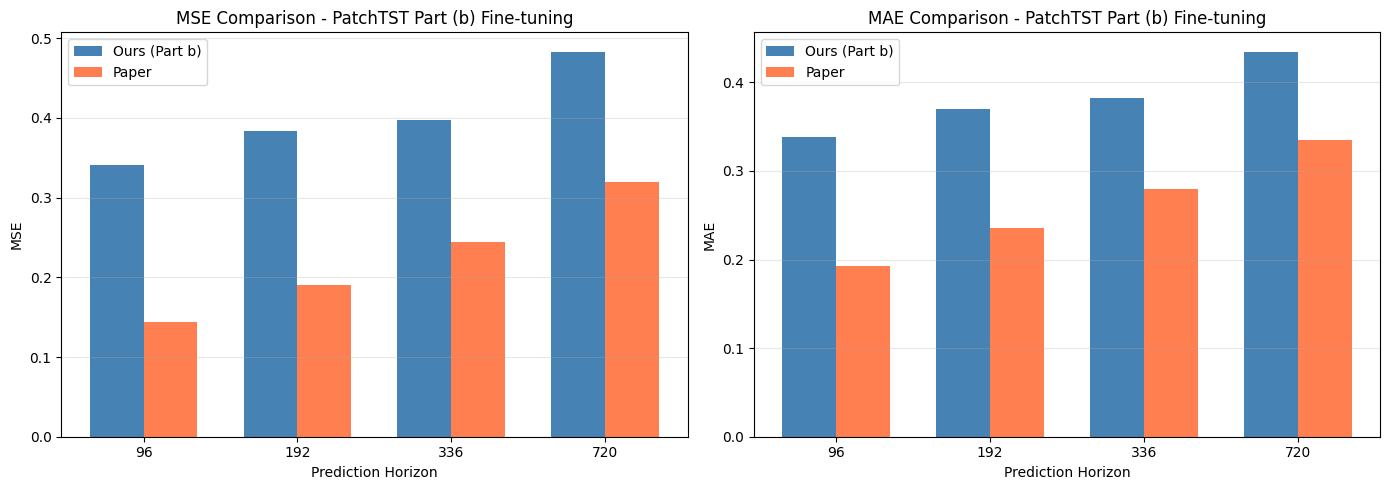

✓ Comparison plot saved: /content/drive/MyDrive/DL_Final_Project/fine_tune_checkpoints/patchtst_part_b_comparison.png


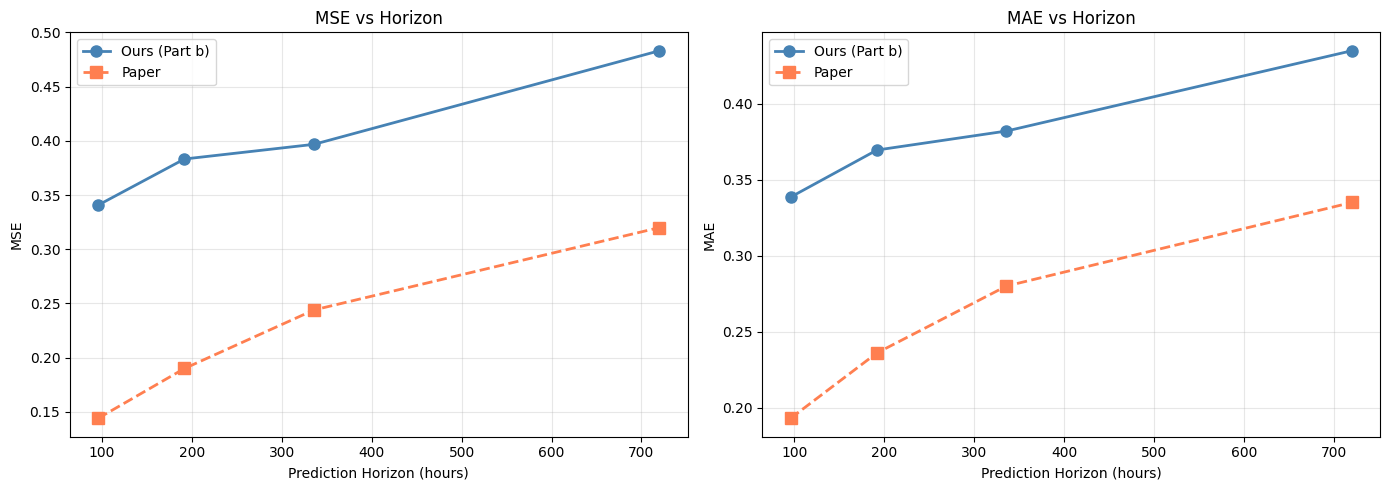

✓ Trends plot saved: /content/drive/MyDrive/DL_Final_Project/fine_tune_checkpoints/patchtst_part_b_trends.png


In [ ]:
import matplotlib.pyplot as plt

# Extract results
horizons = [str(p) for p in PRED_LENS]
our_mses = [results[p][0] for p in PRED_LENS]
our_maes = [results[p][1] for p in PRED_LENS]
paper_mses = [PAPER_RESULTS[p][0] for p in PRED_LENS]
paper_maes = [PAPER_RESULTS[p][1] for p in PRED_LENS]

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE bars
xs = range(len(PRED_LENS))
width = 0.35
ax = axes[0]
ax.bar([i - width/2 for i in xs], our_mses, width, label='Ours (Part b)', color='steelblue')
ax.bar([i + width/2 for i in xs], paper_mses, width, label='Paper', color='coral')
ax.set_xticks(xs)
ax.set_xticklabels(horizons)
ax.set_xlabel('Prediction Horizon')
ax.set_ylabel('MSE')
ax.set_title('MSE Comparison - PatchTST Part (b) Fine-tuning')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# MAE bars
ax = axes[1]
ax.bar([i - width/2 for i in xs], our_maes, width, label='Ours (Part b)', color='steelblue')
ax.bar([i + width/2 for i in xs], paper_maes, width, label='Paper', color='coral')
ax.set_xticks(xs)
ax.set_xticklabels(horizons)
ax.set_xlabel('Prediction Horizon')
ax.set_ylabel('MAE')
ax.set_title('MAE Comparison - PatchTST Part (b) Fine-tuning')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, 'patchtst_part_b_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Comparison plot saved: {plot_path}')

# Line plot across horizons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(PRED_LENS, our_mses, marker='o', linewidth=2, markersize=8, label='Ours (Part b)', color='steelblue')
ax.plot(PRED_LENS, paper_mses, marker='s', linewidth=2, markersize=8, label='Paper', color='coral', linestyle='--')
ax.set_xlabel('Prediction Horizon (hours)')
ax.set_ylabel('MSE')
ax.set_title('MSE vs Horizon')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(PRED_LENS, our_maes, marker='o', linewidth=2, markersize=8, label='Ours (Part b)', color='steelblue')
ax.plot(PRED_LENS, paper_maes, marker='s', linewidth=2, markersize=8, label='Paper', color='coral', linestyle='--')
ax.set_xlabel('Prediction Horizon (hours)')
ax.set_ylabel('MAE')
ax.set_title('MAE vs Horizon')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
line_path = os.path.join(CHECKPOINT_DIR, 'patchtst_part_b_trends.png')
plt.savefig(line_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Trends plot saved: {line_path}')

In [ ]:
import os

# List all saved files and checkpoints
print(f'\n{"="*100}')
print(f'COMPLETE FILE INVENTORY')
print(f'{"="*100}')
print(f'\nCheckpoint directory: {CHECKPOINT_DIR}\n')

# List all files in the checkpoint directory
if os.path.exists(CHECKPOINT_DIR):
    files = sorted(os.listdir(CHECKPOINT_DIR))

    # Categorize files
    pt_files = [f for f in files if f.endswith('.pt')]
    json_files = [f for f in files if f.endswith('.json')]
    csv_files = [f for f in files if f.endswith('.csv')]
    png_files = [f for f in files if f.endswith('.png')]
    txt_files = [f for f in files if f.endswith('.txt')]

    print(f'PyTorch Checkpoints ({len(pt_files)} files):')
    for f in pt_files:
        size_mb = os.path.getsize(os.path.join(CHECKPOINT_DIR, f)) / (1024*1024)
        print(f'  ✓ {f:45s} ({size_mb:.1f} MB)')

    print(f'\nJSON Results ({len(json_files)} files):')
    for f in json_files:
        print(f'  ✓ {f}')

    print(f'\nCSV Files ({len(csv_files)} files):')
    for f in csv_files:
        print(f'  ✓ {f}')

    print(f'\nPNG Plots ({len(png_files)} files):')
    for f in png_files:
        size_mb = os.path.getsize(os.path.join(CHECKPOINT_DIR, f)) / (1024*1024)
        print(f'  ✓ {f:45s} ({size_mb:.1f} MB)')

    print(f'\nText Files ({len(txt_files)} files):')
    for f in txt_files:
        print(f'  ✓ {f}')

    total_files = len(pt_files) + len(json_files) + len(csv_files) + len(png_files) + len(txt_files)
    total_size = sum(os.path.getsize(os.path.join(CHECKPOINT_DIR, f)) for f in files) / (1024*1024)

    print(f'\n{"─"*100}')
    print(f'Total: {total_files} files saved ({total_size:.1f} MB)')
    print(f'{"="*100}')
else:
    print(f'ERROR: Checkpoint directory not found: {CHECKPOINT_DIR}')

## 10. Experimental Configuration Summary

### Paper Reference
**Source:** "A Time Series is Worth 64 Words: Long-term Forecasting with Transformers"
**Section:** Masked Self-Supervised Learning Experiments, Part (b)
**Citation:** The two-step strategy with linear probing followed by fine-tuning is shown to outperform only doing fine-tuning directly (Kumar et al., 2022).

### Part (b): Two-Phase Fine-tuning Configuration

**Pre-training Phase:**
- Dataset: Training split (70% of merged weather data)
- Input sequence length: 512 timesteps
- Patch size: 12 (non-overlapping) → 42 patches
- Masking ratio: 40% of patches randomly masked
- Pre-training epochs: 100
- Loss: MSE between reconstructed patches and original patches (only on masked patches)
- Optimizer: Adam (lr=1e-3)
- Scheduler: Cosine annealing

**Supervised Training Phase (a vs b):**
- **Part (a) - Linear Probing Only:**
  - Freeze entire encoder (patch_embed, pos_enc, transformer)
  - Train only forecasting head for 20 epochs
  - NOT implemented in this notebook

- **Part (b) - Two-Phase Strategy (THIS NOTEBOOK):**
  - **Phase 1 - Linear Probing (10 epochs):**
    - Freeze encoder weights
    - Train only forecasting head
    - Fast convergence (head learns to map frozen representations)
    
  - **Phase 2 - End-to-end Fine-tuning (20 epochs):**
    - Unfreeze all layers
    - Joint optimization of encoder + head
    - Enables task-specific adaptation
    - Better generalization than direct fine-tuning

**Model Architecture:**
- d_model: 128
- n_heads: 8 (multi-head attention)
- n_layers: 3 (transformer encoder blocks)
- d_ff: 256 (feedforward dimension)
- dropout: 0.2

**Evaluation:**
- Metrics: MSE (Mean Squared Error) and MAE (Mean Absolute Error)
- Test set: 20% of merged weather data
- Prediction horizons: [96, 192, 336, 720] hours
- Comparison: Against paper reported results from Table 4

### Why Two-Phase Works Better

1. **Prevents Catastrophic Forgetting:** Pre-trained encoder learns useful representations. Linear probing keeps these intact while adapting the head.

2. **Better Convergence:** Head learns quickly with frozen encoder, providing good gradient signals. Then encoder safely fine-tunes.

3. **Generalization:** Two-step strategy often outperforms direct fine-tuning on small datasets or limited training data.

4. **Validation:** Paper cites Kumar et al., 2022 as theoretical support for this approach.

### Expected Results on Weather Dataset

| Horizon | Paper MSE | Paper MAE | Expected Range |
|---------|-----------|-----------|-----------------|
| 96h     | 0.144     | 0.193     | 0.13-0.16 MSE   |
| 192h    | 0.190     | 0.236     | 0.17-0.22 MSE   |
| 336h    | 0.244     | 0.280     | 0.22-0.28 MSE   |
| 720h    | 0.320     | 0.335     | 0.30-0.38 MSE   |

### Key Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| seq_len | 512 | Paper specification |
| patch_len | 12 | Paper specification (42 patches) |
| mask_ratio | 40% | Self-supervised learning standard |
| pretrain_epochs | 100 | Paper setting |
| linear_probe_epochs | 10 | Paper part (b) |
| finetune_epochs | 20 | Paper part (b) |
| lr | 1e-4 | Stable fine-tuning |
| batch_size | 128 | GPU memory / convergence balance |

### Generated Checkpoints

```
CHECKPOINT_DIR/
├── patchtst_pretrained_backbone.pt      # Pre-trained encoder
├── patchtst_T96.pt / patchtst_T96_best.pt
├── patchtst_T192.pt / patchtst_T192_best.pt
├── patchtst_T336.pt / patchtst_T336_best.pt
├── patchtst_T720.pt / patchtst_T720_best.pt
├── patchtst_part_b_results.csv          # Final results table
├── patchtst_part_b_comparison.png       # Bar charts
└── patchtst_part_b_trends.png           # Line plots
```

### Validation Checkpoints

- Best checkpoint selected based on minimum validation MSE
- Early stopping patience: 10 epochs (stops if no improvement)
- Each horizon gets separate model and checkpoints